# SPIN — Example 3: Fisher-KPP (long-horizon prediction)

This notebook reproduces the **Fisher-KPP** results from the paper (Fig. 5 and the
Fisher-KPP panel of Fig. 6), the most demanding test.

A localized pulse grows through the reaction term, develops two travelling fronts,
and saturates toward $u\approx 1$ over much of the domain. As in the Burgers case
we build a **rank-4** hyper-reduced LSPG-QDEIM ROM from only the **first 4**
full-order snapshots and predict **500 steps**. We compare the **static**,
**baseline adaptive**, and **SPIN** ROMs — identical rank, sample count, and
correction schedule; the only difference is SPIN's in-span channel.


## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import spin
from spin.core import compute_pod_basis, qdeim
from spin.problems.fisher_kpp import FisherKPPSolver, FisherKPPSpinROM
from spin.diagnostics import relative_l2_error
from spin.utils import use_paper_style, PALETTE, plot_profiles, plot_error_history
use_paper_style()

## 2 · Control variables

The forgetting factors are `GAMMA_OUT_BASELINE=0.1` for the baseline and
`(GAMMA_IN, GAMMA_OUT)=(0.9, 0.25)` for SPIN. Note the correction interval
here is `ZS=25` (less frequent than Burgers).

In [2]:
# --- full-order model -------------------------------------------------
NX     = 256       # spatial grid points
L      = 1.0       # domain length
D      = 1e-4      # diffusivity
ALPHA  = 20.0      # reaction rate (beta)
DT     = 1e-3      # time step
N_STEPS = 500      # prediction horizon

# --- reduced-order model ---------------------------------------------
R       = 4        # ROM rank
M       = 4        # QDEIM sample points
OFFLINE = 4        # number of training snapshots for the offline POD basis
ZS      = 25       # out-of-span correction interval

# --- forgetting factors (from the paper's ablation) ------------------
GAMMA_OUT_BASELINE = 0.1    # baseline adaptive: out-of-span forgetting
GAMMA_IN_SPIN      = 0.9    # SPIN: in-span forgetting
GAMMA_OUT_SPIN     = 0.25   # SPIN: out-of-span forgetting

# Newton tolerances of the reference run (these exact values reproduce the paper)
FOM_TOL = 1e-10            # full-order snapshot generation
TOL, MAX_ITER = 1e-8, 10  # ROM Newton tolerance

## 3 · Full-order model and offline basis

In [3]:
solver = FisherKPPSolver(Nx=NX, L=L, D=D, alpha=ALPHA, dt=DT)
snaps = solver.simulate(solver.initial_condition(), n_steps=N_STEPS, tol=FOM_TOL)

Phi0, sigma0 = compute_pod_basis(snaps[:, :OFFLINE], R)
p_inds = qdeim(Phi0, M)
a0 = Phi0.T @ snaps[:, 0]
x = solver.x
print(f"FOM snapshots: {snaps.shape},  basis: {Phi0.shape},  samples: {p_inds}")

FOM snapshots: (256, 501),  basis: (256, 4),  samples: [128 115 104  89]


## 4 · Run the three ROMs

In [4]:
def run(mode, gamma_in=1.0, gamma_out=0.25, record=False):
    rom = FisherKPPSpinROM(Phi0.copy(), sigma0.copy(), p_inds.copy(),
                           dt=DT, D=D, alpha=ALPHA, dx=solver.dx, zs=ZS,
                           mode=mode, gamma_in=gamma_in, gamma_out=gamma_out)
    return rom.simulate(a0.copy(), N_STEPS, tol=TOL, max_iter=MAX_ITER, record=record)

soln_static   = run("static")
soln_baseline = run("baseline", gamma_out=GAMMA_OUT_BASELINE)
soln_spin     = run("spin", gamma_in=GAMMA_IN_SPIN, gamma_out=GAMMA_OUT_SPIN)

err_static   = relative_l2_error(soln_static,   snaps)
err_baseline = relative_l2_error(soln_baseline, snaps)
err_spin     = relative_l2_error(soln_spin,     snaps)

print("mean relative L2 error over the horizon:")
print(f"  static            = {err_static.mean():.3e}")
print(f"  baseline adaptive = {err_baseline.mean():.3e}")
print(f"  SPIN              = {err_spin.mean():.3e}")

mean relative L2 error over the horizon:
  static            = 2.079e-01
  baseline adaptive = 1.201e-01
  SPIN              = 7.812e-03


SPIN shows a much larger separation from the baseline than in Burgers, because the saturating fronts are harder for a fixed-rank basis to track.

## 5 · Solution profiles

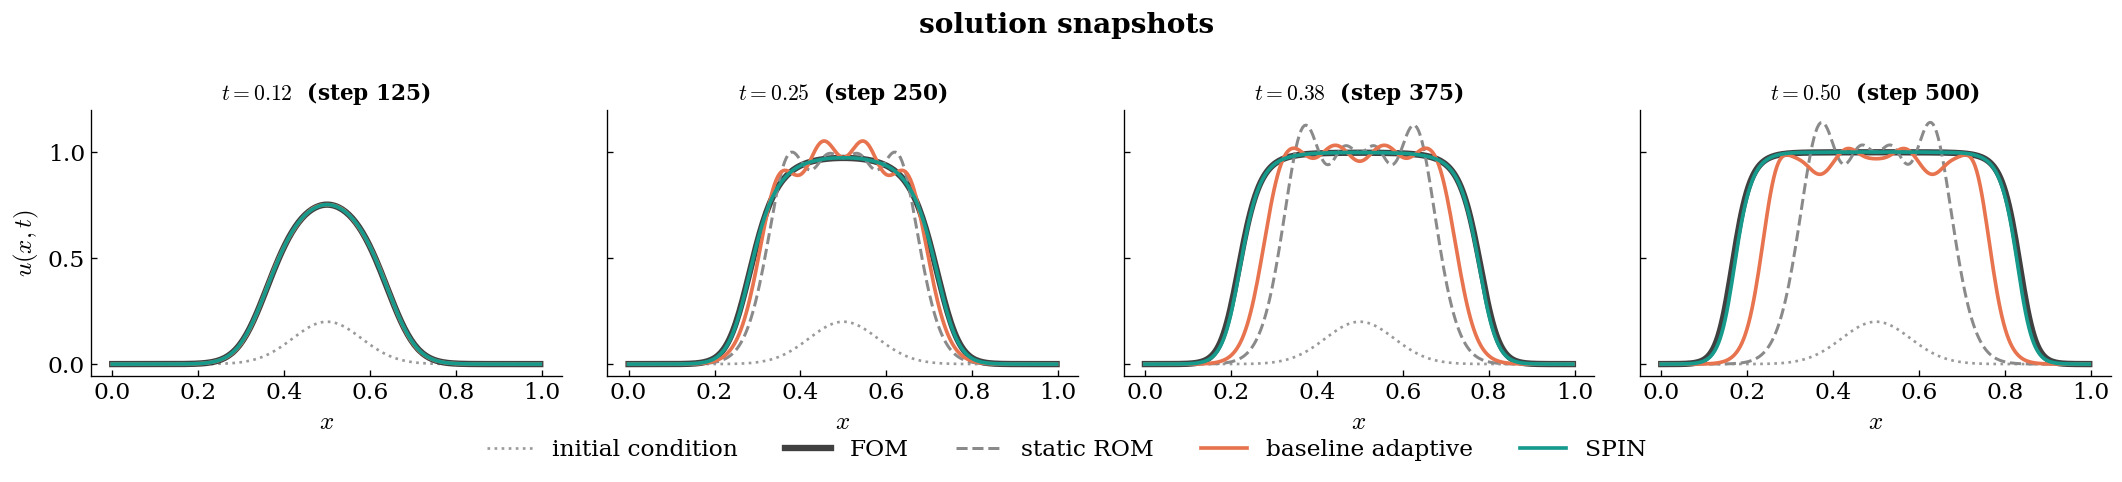

In [5]:
snap_steps = [N_STEPS//4, N_STEPS//2, 3*N_STEPS//4, N_STEPS]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
plot_profiles(axes, x, snaps[:, 0], snaps, soln_static, soln_baseline, soln_spin,
              snap_steps, DT)
axes[0].set_ylabel(r"$u(x,t)$")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("solution snapshots", fontweight="bold"); fig.tight_layout(); plt.show()

## 6 · Space-time fields and error

Top row: the space-time solution $u(x,t)$ for FOM / baseline / SPIN. Bottom row: the relative-$L_2$ error history, and the pointwise absolute error fields. SPIN tracks the fronts visibly more cleanly.

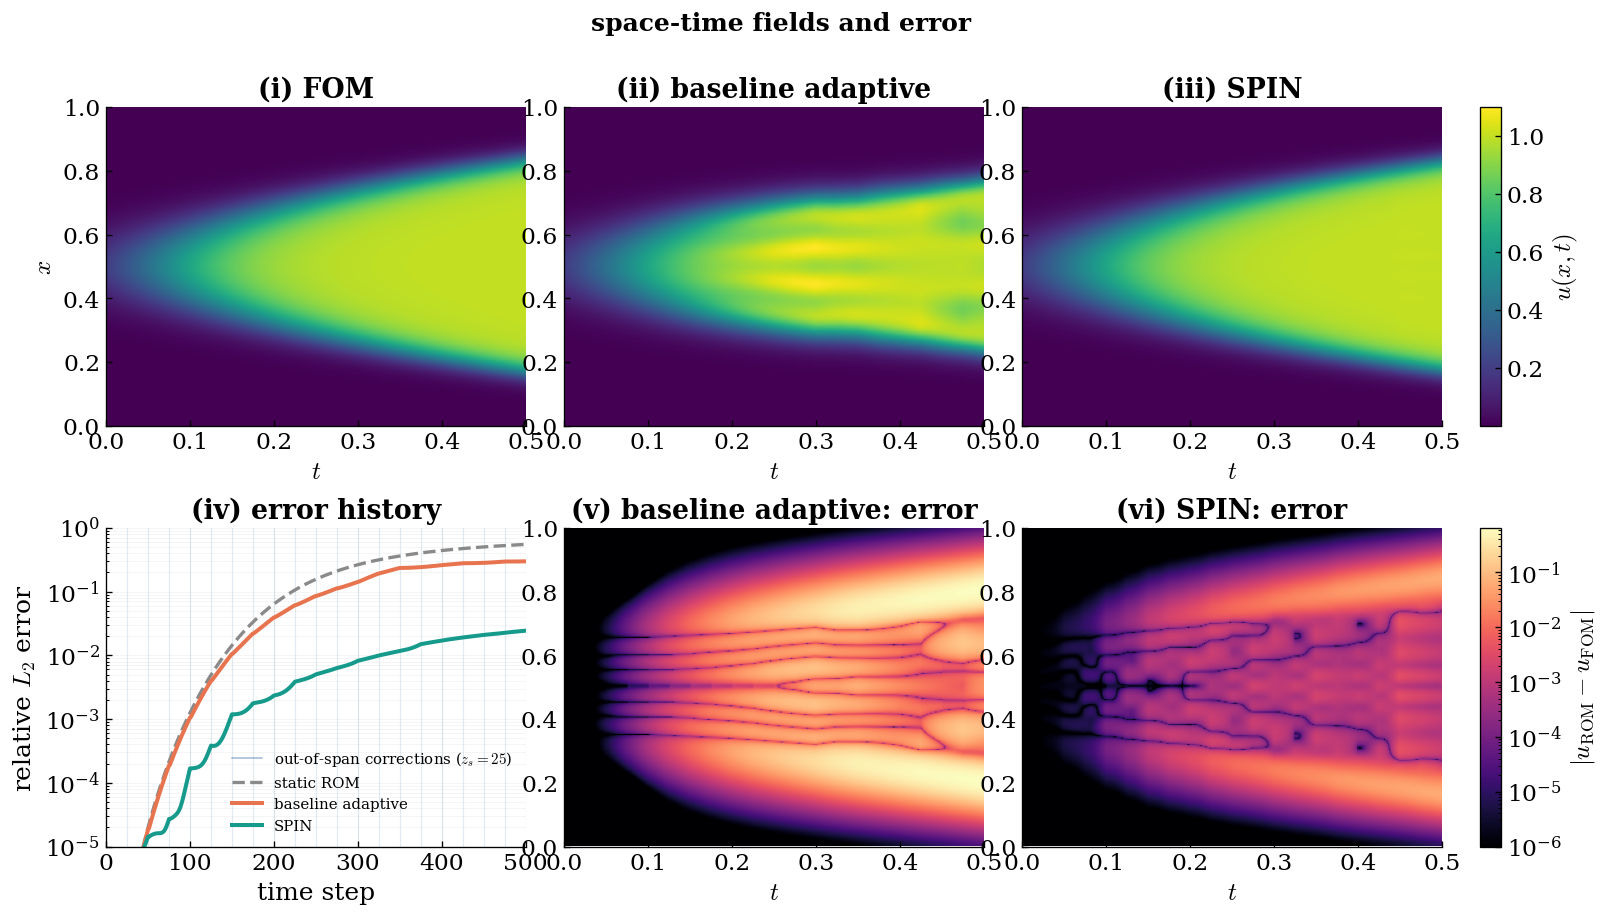

In [6]:
import matplotlib.gridspec as gridspec
extent = [0, N_STEPS*DT, 0, L]
ef_b = np.abs(soln_baseline - snaps); ef_s = np.abs(soln_spin - snaps)
pos = np.concatenate([ef_b[ef_b > 0], ef_s[ef_s > 0]])
enorm = LogNorm(vmin=max(1e-6, np.percentile(pos, 1)), vmax=max(ef_b.max(), ef_s.max()))
u_vmin, u_vmax = snaps.min(), max(snaps.max(), soln_baseline.max(), soln_spin.max())

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.05],
                       wspace=0.12, hspace=0.32)
top = [("(i) FOM", snaps), ("(ii) baseline adaptive", soln_baseline), ("(iii) SPIN", soln_spin)]
for j, (ttl, fld) in enumerate(top):
    ax = fig.add_subplot(gs[0, j])
    im_u = ax.imshow(fld, origin="lower", aspect="auto", extent=extent, cmap="viridis",
                     vmin=u_vmin, vmax=u_vmax)
    ax.set_title(ttl); ax.set_xlabel(r"$t$")
    if j == 0: ax.set_ylabel(r"$x$")
fig.colorbar(im_u, cax=fig.add_subplot(gs[0, 3]), label=r"$u(x,t)$")

ax = fig.add_subplot(gs[1, 0])
plot_error_history(ax, err_static, err_baseline, err_spin, ZS, title="(iv) error history")
ax.set_ylim(1e-5, 1e0); ax.legend(loc="lower right", fontsize=9)
for j, (ttl, ef) in enumerate([("(v) baseline adaptive: error", ef_b), ("(vi) SPIN: error", ef_s)]):
    ax = fig.add_subplot(gs[1, j+1])
    im_e = ax.imshow(ef, origin="lower", aspect="auto", extent=extent, cmap="magma", norm=enorm)
    ax.set_title(ttl); ax.set_xlabel(r"$t$")
fig.colorbar(im_e, cax=fig.add_subplot(gs[1, 3]), label=r"$|u_{\rm ROM}-u_{\rm FOM}|$")
fig.suptitle("space-time fields and error", fontweight="bold", fontsize=15); plt.show()

## 7 · Spectral diagnostics

The same diagnostics as the Burgers notebook. Unlike the spiral (where one mode
is strongly suppressed), the PDE spectra show a richer regime: with
$\gamma_{\rm in}\approx1$ several retained modes are repeatedly *reinforced*
between corrections, while the basis still rotates inside an essentially fixed
subspace.

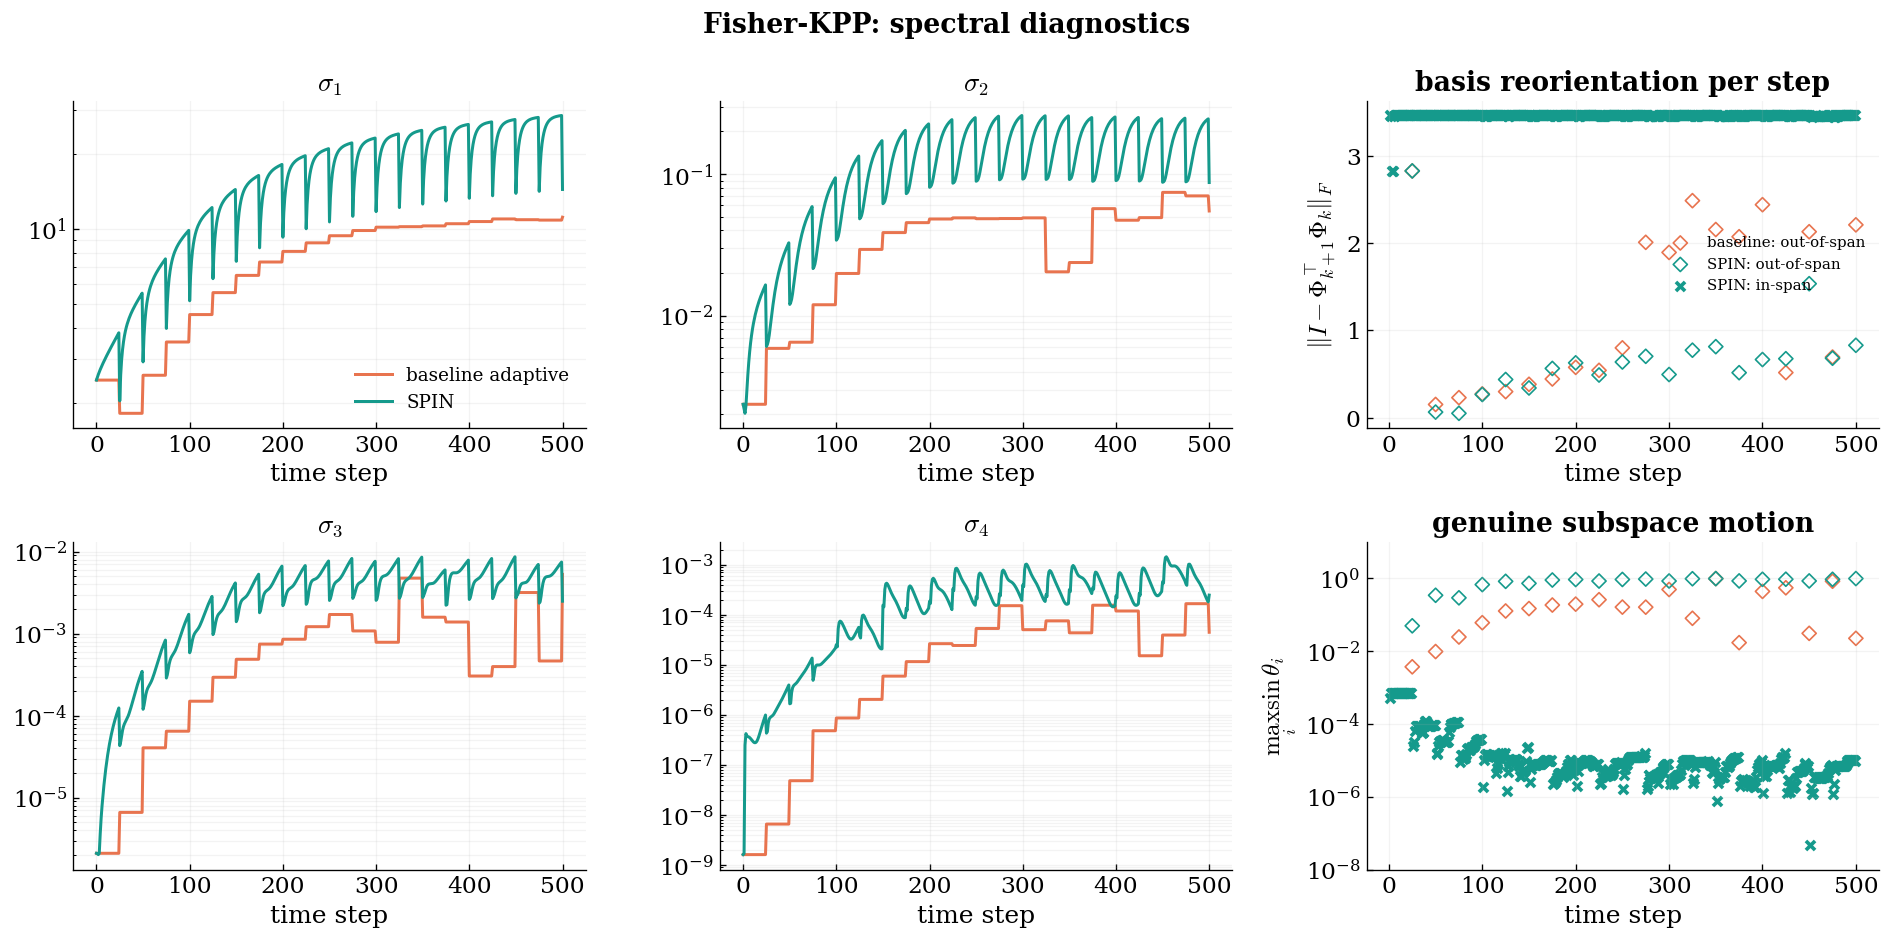

In [7]:
_, hist_baseline = run("baseline", gamma_out=GAMMA_OUT_BASELINE, record=True)
_, hist_spin     = run("spin", gamma_in=GAMMA_IN_SPIN, gamma_out=GAMMA_OUT_SPIN, record=True)

steps = hist_spin["step"]
Sb, Ss = hist_baseline["sigma"], hist_spin["sigma"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, ax in zip(range(R), [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    ax.semilogy(steps, Sb[:, j], color=PALETTE["baseline"], lw=1.8, label="baseline adaptive")
    ax.semilogy(steps, Ss[:, j], color=PALETTE["spin"], lw=1.8, label="SPIN")
    ax.set_title(rf"$\sigma_{{{j+1}}}$"); ax.set_xlabel("time step"); ax.grid(alpha=0.15, which="both")
axes[0,0].legend(fontsize=11)

kb, ks = np.array(hist_baseline["kind"]), np.array(hist_spin["kind"])
ax = axes[0, 2]
rb, rs = hist_baseline["basis_reorientation"], hist_spin["basis_reorientation"]
ax.scatter(steps[kb=="out"], rb[kb=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["baseline"], s=36, label="baseline: out-of-span")
ax.scatter(steps[ks=="out"], rs[ks=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["spin"], s=36, label="SPIN: out-of-span")
ax.scatter(steps[ks=="in"], rs[ks=="in"], marker="x", c=PALETTE["spin"], s=30, label="SPIN: in-span")
ax.set_title("basis reorientation per step"); ax.set_xlabel("time step")
ax.set_ylabel(r"$\|I-\Phi_{k+1}^\top\Phi_k\|_F$"); ax.legend(fontsize=9, loc="center right"); ax.grid(alpha=0.15)

ax = axes[1, 2]
sb = np.maximum(hist_baseline["subspace_change"], 1e-16)
ss = np.maximum(hist_spin["subspace_change"], 1e-16)
ax.scatter(steps[kb=="out"], sb[kb=="out"], marker="D", facecolors="none", edgecolors=PALETTE["baseline"], s=36)
ax.scatter(steps[ks=="out"], ss[ks=="out"], marker="D", facecolors="none", edgecolors=PALETTE["spin"], s=36)
ax.scatter(steps[ks=="in"], ss[ks=="in"], marker="x", c=PALETTE["spin"], s=30)
ax.set_yscale("log"); ax.set_ylim(1e-8, 1e1); ax.set_title("genuine subspace motion")
ax.set_xlabel("time step"); ax.set_ylabel(r"$\max_i \sin\theta_i$"); ax.grid(alpha=0.15, which="both")
fig.suptitle("Fisher-KPP: spectral diagnostics", fontweight="bold", fontsize=16)
fig.tight_layout(); plt.show()

---
**Takeaway.** On this harder, saturating front problem the gap between SPIN and
the baseline is large (SPIN error ~15× smaller) — again with the same correction
budget. In-span learning makes the spectral state trajectory-informed, so each
external correction lands on a basis already prepared for it.